## 🌲 PARAMETROS MAS COMUNES PARA OPTIMIZAR EL MODELO DE RANDOM FOREST

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = sns.load_dataset('titanic').dropna()
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False
872,0,1,male,33.0,0,0,5.0000,S,First,man,True,B,Southampton,no,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True


# MODELO DE CLASIFICACIÓN CON RANDOM FOREST

## PASO 1 IDENFITICAR VARIABLE X Y Y

In [3]:
cols = ['pclass','sex','age','sibsp','parch','fare','embarked']
target = 'survived'
X = df[cols]
y = df[target]

In [4]:
X.dtypes

,0
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object


In [5]:
X = pd.get_dummies(X,columns=['sex','embarked'],drop_first=True)

 ## PASO 2 DIVIDIR DATASET EN ENTRENAMIENTO Y PRUEBA

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## PASO 3 - ENTRENAMIENTO DEL MODELO

In [8]:
model = RandomForestClassifier()
model.fit(X_train,y_train)

RandomForestClassifier()

## PASO 4 - EVALUAMOS EL MODELO

In [9]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
print(f'Accuracy : {accuracy:.2f}')

Accuracy : 0.73


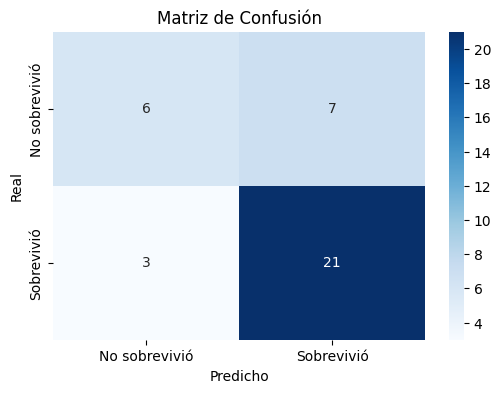

In [10]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No sobrevivió', 'Sobrevivió'], yticklabels=['No sobrevivió', 'Sobrevivió'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

#  Principales parámetros de RandomForestClassifier

## `n_estimators` (default=100)
- Especifica el número de árboles en el bosque.
- Más árboles generalmente mejoran la precisión, pero aumentan el tiempo de entrenamiento y predicción.
- **Ejemplo**: `n_estimators=100` indica que se entrenarán 100 árboles.

In [11]:
model2 = RandomForestClassifier(n_estimators=5)
model2.fit(X_train,y_train)

y_pred = model2.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
print(f'Accuracy : {accuracy:.2f}')

Accuracy : 0.73


## `criterion` (default="gini")
- Define la función para medir la calidad de una división en los nodos del árbol.  
- **Opciones**:
  - `"gini"`: usa el índice de Gini para calcular la impureza.
  - `"entropy"`: usa la ganancia de información (entropía) para calcular la impureza.

In [13]:
model3 = RandomForestClassifier(criterion='entropy')
model3.fit(X_train,y_train)

y_pred = model3.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
print(f'Accuracy : {accuracy:.2f}')

Accuracy : 0.70


## `max_depth` (default=None)
- Controla la profundidad máxima de cada árbol.
- `None` significa que los nodos se expanden hasta que todas las hojas sean puras o contengan menos de `min_samples_split` muestras.
- Un valor menor puede reducir el sobreajuste.

In [14]:
model4 = RandomForestClassifier(max_depth=10)
model4.fit(X_train,y_train)

y_pred = model4.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
print(f'Accuracy : {accuracy:.2f}')

Accuracy : 0.76


## `min_samples_split` (default=2)
- Mínimo número de muestras requeridas para dividir un nodo.
- Un valor alto impide que el modelo haga divisiones profundas y ayuda a reducir el sobreajuste.

In [15]:
model5 = RandomForestClassifier(min_samples_split=3)
model5.fit(X_train,y_train)

y_pred = model5.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
print(f'Accuracy : {accuracy:.2f}')

Accuracy : 0.70


## `min_samples_leaf` (default=1)
- Número mínimo de muestras que debe tener una hoja (nodo terminal).
- Evita la creación de hojas con muy pocas muestras, lo que puede mejorar la generalización.

In [16]:
model6 = RandomForestClassifier(min_samples_leaf=5)
model6.fit(X_train,y_train)

y_pred = model6.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
print(f'Accuracy : {accuracy:.2f}')

Accuracy : 0.68


## `max_features` (default="sqrt")
- Número máximo de características a considerar en cada división.
- **Opciones**:
  - `"sqrt"`: en cada división se consideran `sqrt(n_features)`.
  - `"log2"`: usa `log2(n_features)`.
  - `None`: usa todas las características.

In [17]:
model7 = RandomForestClassifier(max_features='log2')
model7.fit(X_train,y_train)

y_pred = model7.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
print(f'Accuracy : {accuracy:.2f}')

Accuracy : 0.70


## `bootstrap` (default=True)
- Si `True`, se usa muestreo con reemplazo para entrenar cada árbol con una muestra diferente del conjunto de datos.
- Si `False`, se usa todo el conjunto de datos en cada árbol.

In [18]:
model8 = RandomForestClassifier(bootstrap=False)
model8.fit(X_train,y_train)

y_pred = model8.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
print(f'Accuracy : {accuracy:.2f}')

Accuracy : 0.70


## `random_state` (default=None)
- Fija la semilla para hacer el experimento reproducible.
- **Ejemplo**: `random_state=42` asegura que los resultados sean consistentes en cada ejecución.

In [20]:
model9 = RandomForestClassifier(random_state=42)
model9.fit(X_train,y_train)

y_pred = model9.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
print(f'Accuracy : {accuracy:.2f}')

Accuracy : 0.73


## `n_jobs` (default=None)
- Número de núcleos del procesador a usar en paralelo.
- `-1` usa todos los núcleos disponibles para acelerar el entrenamiento.

In [21]:
model10 = RandomForestClassifier(n_jobs=-1)
model10.fit(X_train,y_train)

y_pred = model10.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
print(f'Accuracy : {accuracy:.2f}')

Accuracy : 0.68
